In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the unified dataset
data = pd.read_csv("../data/raw/ethiopia_fi_unified_data.csv")

# Load the reference codes
reference = pd.read_csv("../data/raw/reference_codes.csv")

print("Unified Dataset Shape:", data.shape)
print("Reference Codes Shape:", reference.shape)

Unified Dataset Shape: (43, 34)
Reference Codes Shape: (71, 4)


In [4]:
# Display first five rows
data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [5]:
data.columns

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            43 non-null     object 
 1   record_type          43 non-null     object 
 2   category             10 non-null     object 
 3   pillar               33 non-null     object 
 4   indicator            43 non-null     object 
 5   indicator_code       43 non-null     object 
 6   indicator_direction  33 non-null     object 
 7   value_numeric        33 non-null     float64
 8   value_text           10 non-null     object 
 9   value_type           43 non-null     object 
 10  unit                 33 non-null     object 
 11  observation_date     43 non-null     object 
 12  period_start         10 non-null     object 
 13  period_end           10 non-null     object 
 14  fiscal_year          43 non-null     object 
 15  gender               43 non-null     objec

In [7]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,43,43,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,43,3,observation,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,10,7,product_launch,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,33,4,ACCESS,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,43,29,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,43,29,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,33,3,higher_better,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,33.0,NaN,NaN,NaN,94372576990.694839,423106092501.167664,1.08,24.0,61.4,15000000.0,2380000000000.0
value_text,10,3,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,43,6,percentage,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
record_counts = data["record_type"].value_counts()

print(record_counts)

record_type
observation    30
event          10
target          3
Name: count, dtype: int64


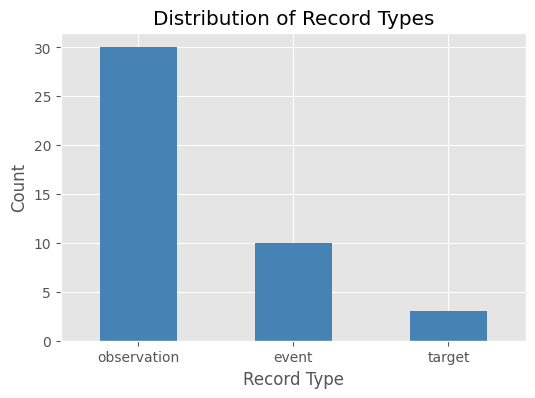

In [9]:
plt.figure(figsize=(6,4))
record_counts.plot(kind="bar", color="steelblue")

plt.title("Distribution of Record Types")
plt.xlabel("Record Type")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [10]:
pillar_counts = data["pillar"].fillna("Not Applicable").value_counts()

print(pillar_counts)

pillar
ACCESS            16
USAGE             11
Not Applicable    10
GENDER             5
AFFORDABILITY      1
Name: count, dtype: int64


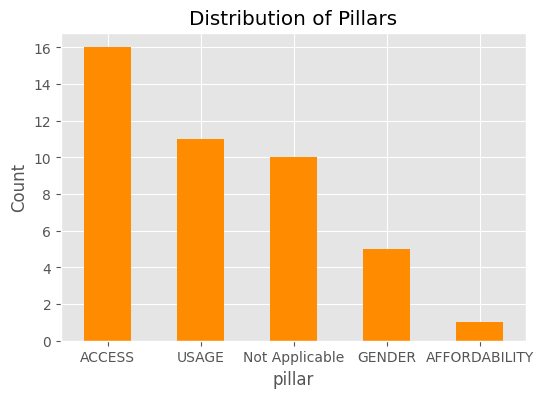

In [11]:
plt.figure(figsize=(6,4))
pillar_counts.plot(kind="bar", color="darkorange")

plt.title("Distribution of Pillars")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [12]:
source_counts = data["source_type"].value_counts()

print(source_counts)

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64


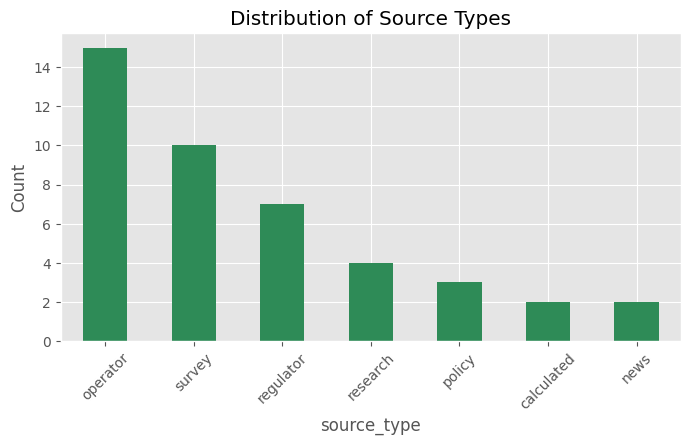

In [13]:
plt.figure(figsize=(8,4))
source_counts.plot(kind="bar", color="seagreen")

plt.title("Distribution of Source Types")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [14]:
confidence_counts = data["confidence"].value_counts()

print(confidence_counts)

confidence
high      40
medium     3
Name: count, dtype: int64


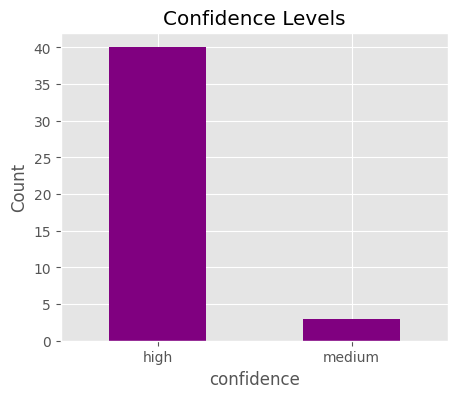

In [15]:
plt.figure(figsize=(5,4))
confidence_counts.plot(kind="bar", color="purple")

plt.title("Confidence Levels")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [16]:
# Convert observation_date to datetime
data["observation_date"] = pd.to_datetime(data["observation_date"])

# Verify the data type
data["observation_date"].dtype

dtype('<M8[ns]')

In [17]:
print("Earliest Date:", data["observation_date"].min())
print("Latest Date:", data["observation_date"].max())

Earliest Date: 2014-12-31 00:00:00
Latest Date: 2030-12-31 00:00:00


In [18]:
observations = data[data["record_type"] == "observation"]

print("Earliest Observation:", observations["observation_date"].min())
print("Latest Observation:", observations["observation_date"].max())

Earliest Observation: 2014-12-31 00:00:00
Latest Observation: 2025-12-31 00:00:00


In [19]:
observations["year"] = observations["observation_date"].dt.year

observations["year"].value_counts().sort_index()

/var/folders/bh/mxb5mh_n47zf935p657g4cp00000gn/T/ipykernel_5826/1555414431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  observations["year"] = observations["observation_date"].dt.year


year
2014     1
2017     1
2021     5
2023     1
2024    11
2025    11
Name: count, dtype: int64

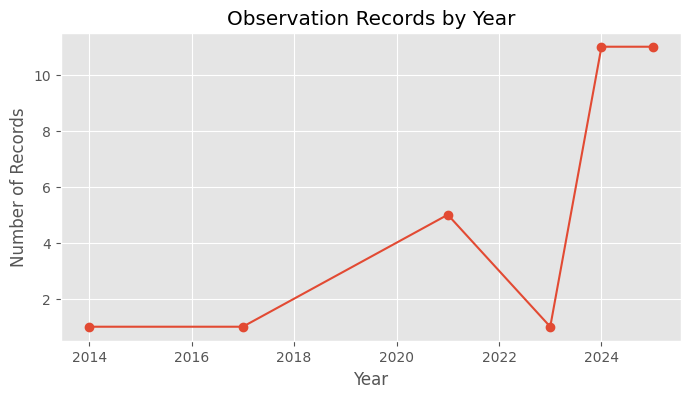

In [20]:
year_counts = observations["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))

year_counts.plot(marker="o")

plt.title("Observation Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.grid(True)

plt.show()

In [21]:
observations[["indicator", "indicator_code"]].drop_duplicates().sort_values("indicator")

,indicator,indicator_code
8,4G Population Coverage,ACC_4G_COV
17,ATM Transaction Count,USG_ATM_COUNT
18,ATM Transaction Value,USG_ATM_VALUE
26,Account Ownership Gender Gap,GEN_GAP_ACC
0,Account Ownership Rate,ACC_OWNERSHIP
25,Data Affordability Index,AFF_DATA_INCOME
11,Fayda Digital ID Enrollment,ACC_FAYDA
28,Female Mobile Money Account Share,GEN_MM_SHARE
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE
22,M-Pesa Registered Users,USG_MPESA_USERS


In [22]:
indicator_counts = (
    observations.groupby(["indicator", "indicator_code"])
    .size()
    .reset_index(name="Number of Observations")
    .sort_values("Number of Observations", ascending=False)
)

indicator_counts

,indicator,indicator_code,Number of Observations
4,Account Ownership Rate,ACC_OWNERSHIP,6
6,Fayda Digital ID Enrollment,ACC_FAYDA,3
0,4G Population Coverage,ACC_4G_COV,2
3,Account Ownership Gender Gap,GEN_GAP_ACC,2
14,P2P Transaction Count,USG_P2P_COUNT,2
10,Mobile Money Account Rate,ACC_MM_ACCOUNT,2
12,Mobile Phone Gender Gap,GEN_GAP_MOBILE,1
17,Telebirr Registered Users,USG_TELEBIRR_USERS,1
16,P2P/ATM Crossover Ratio,USG_CROSSOVER,1
15,P2P Transaction Value,USG_P2P_VALUE,1


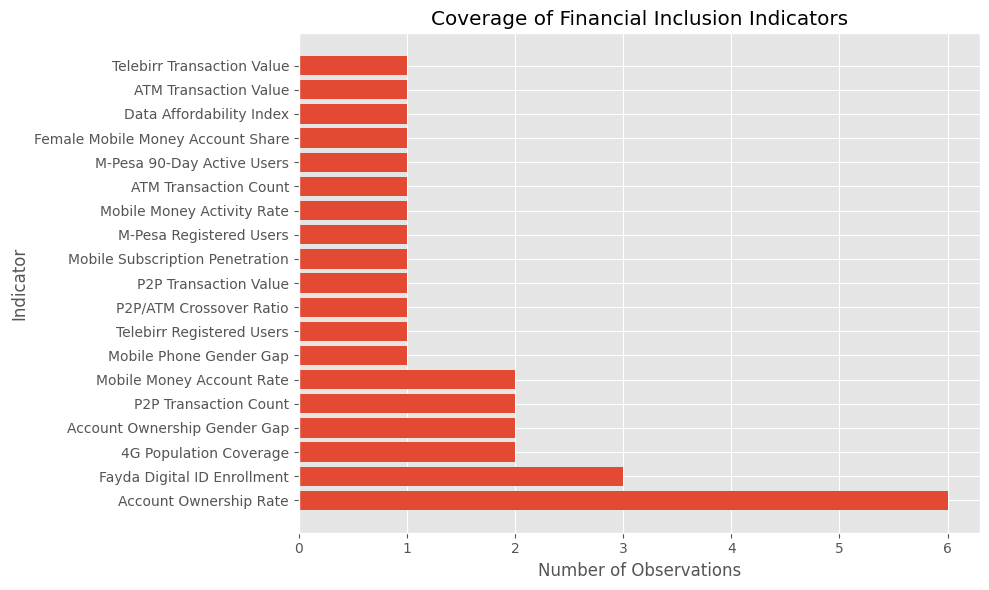

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    indicator_counts["indicator"],
    indicator_counts["Number of Observations"]
)

plt.title("Coverage of Financial Inclusion Indicators")
plt.xlabel("Number of Observations")
plt.ylabel("Indicator")

plt.tight_layout()
plt.show()

In [24]:
events = data[data["record_type"] == "event"].copy()

print(f"Number of events: {len(events)}")
events.head()

Number of events: 10


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaN,NaN,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaN,NaN,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaN,NaN,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN


In [25]:
events[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date",
        "source_name",
        "confidence"
    ]
].sort_values("observation_date")

,record_id,indicator,category,observation_date,source_name,confidence
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01,NBE,high
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,Safaricom,high
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,NIDP,high
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29,NBE,high
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01,EthSwitch,high
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27,EthSwitch,high
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15,News,high
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18,NBE/EthSwitch,high


In [26]:
events["category"].value_counts()

category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

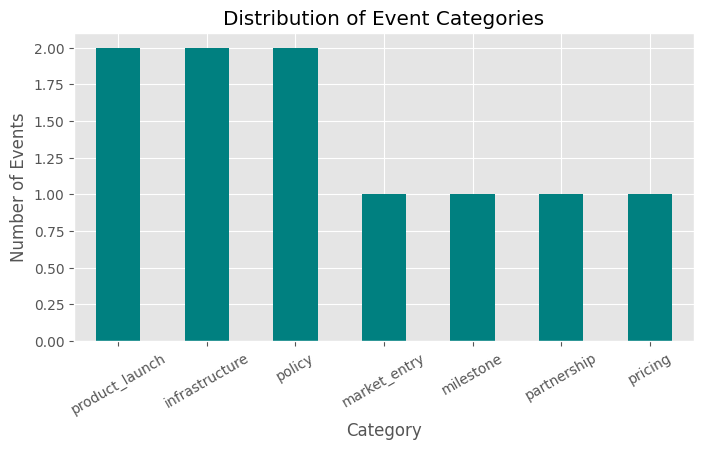

In [27]:
plt.figure(figsize=(8,4))

events["category"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("Distribution of Event Categories")
plt.xlabel("Category")
plt.ylabel("Number of Events")

plt.xticks(rotation=30)

plt.show()

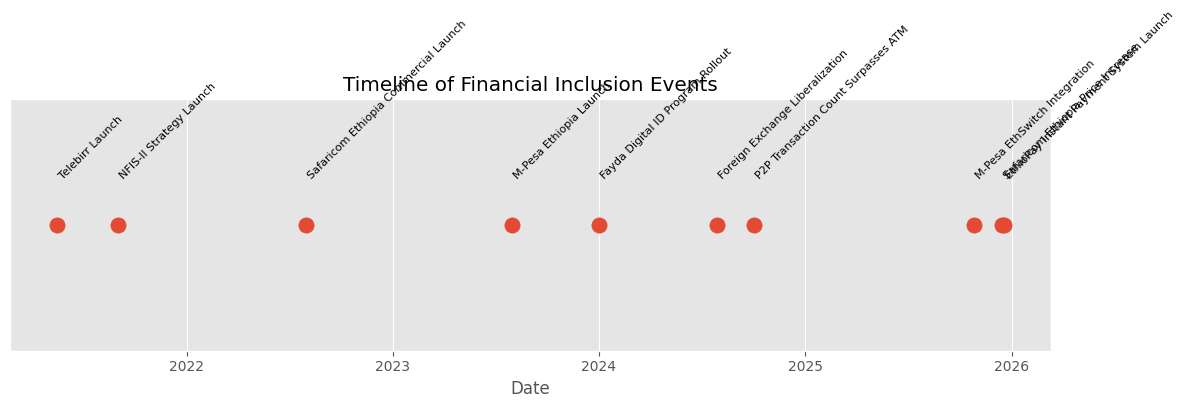

In [28]:
events = events.sort_values("observation_date")

plt.figure(figsize=(12,4))

plt.scatter(
    events["observation_date"],
    [1] * len(events),
    s=120
)

for _, row in events.iterrows():
    plt.text(
        row["observation_date"],
        1.02,
        row["indicator"],
        rotation=45,
        fontsize=8
    )

plt.yticks([])
plt.title("Timeline of Financial Inclusion Events")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

In [29]:
missing = data.isnull().sum()

missing = (
    missing[missing > 0]
    .sort_values(ascending=False)
)

missing

related_indicator      43
region                 43
evidence_basis         43
lag_months             43
impact_estimate        43
impact_magnitude       43
impact_direction       43
relationship_type      43
notes                  43
period_end             33
period_start           33
value_text             33
collection_date        33
category               33
source_url             12
pillar                 10
unit                   10
value_numeric          10
indicator_direction    10
original_text          10
dtype: int64

In [30]:
missing_percent = (
    data.isnull().mean() * 100
).round(2)

missing_percent = (
    missing_percent[missing_percent > 0]
    .sort_values(ascending=False)
)

missing_percent

related_indicator      100.00
region                 100.00
evidence_basis         100.00
lag_months             100.00
impact_estimate        100.00
impact_magnitude       100.00
impact_direction       100.00
relationship_type      100.00
notes                  100.00
period_end              76.74
period_start            76.74
value_text              76.74
collection_date         76.74
category                76.74
source_url              27.91
pillar                  23.26
unit                    23.26
value_numeric           23.26
indicator_direction     23.26
original_text           23.26
dtype: float64

In [31]:
events = data[data["record_type"] == "event"]

events[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date"
    ]
].sort_values("observation_date")

,record_id,indicator,category,observation_date
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18


In [32]:
new_observations = pd.DataFrame(columns=data.columns)

new_observations

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [33]:
new_record = {
    "record_id": "OBS_0031",
    "record_type": "observation",
    "category": np.nan,
    "pillar": "USAGE",
    "indicator": "Smartphone Penetration",
    "indicator_code": "SMARTPHONE_PEN",
    "indicator_direction": "higher_better",
    "value_numeric": None,           # We'll fill this after collecting the value
    "value_text": np.nan,
    "value_type": "percentage",
    "unit": "%",
    "observation_date": "2024-12-31",
    "period_start": np.nan,
    "period_end": np.nan,
    "fiscal_year": "2024",
    "gender": "all",
    "location": "national",
    "region": np.nan,
    "source_name": "",
    "source_type": "report",
    "source_url": "",
    "confidence": "high",
    "related_indicator": np.nan,
    "relationship_type": np.nan,
    "impact_direction": np.nan,
    "impact_magnitude": np.nan,
    "impact_estimate": np.nan,
    "lag_months": np.nan,
    "evidence_basis": np.nan,
    "comparable_country": "",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "original_text": "",
    "notes": "Added for forecasting digital financial inclusion."
}

In [34]:
new_observations = pd.concat(
    [new_observations, pd.DataFrame([new_record])],
    ignore_index=True
)

new_observations

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,OBS_0031,observation,NaN,USAGE,Smartphone Penetration,SMARTPHONE_PEN,higher_better,None,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,,report,,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,,Added for forecasting digital financial inclusion.


In [35]:
mobile_internet = {
    "record_id": "OBS_0032",
    "record_type": "observation",
    "category": np.nan,
    "pillar": "USAGE",
    "indicator": "Mobile Internet Usage",
    "indicator_code": "MOBILE_NET",
    "indicator_direction": "higher_better",
    "value_numeric": None,
    "value_text": np.nan,
    "value_type": "percentage",
    "unit": "%",
    "observation_date": "2024-12-31",
    "period_start": np.nan,
    "period_end": np.nan,
    "fiscal_year": "2024",
    "gender": "all",
    "location": "national",
    "region": np.nan,
    "source_name": "",
    "source_type": "report",
    "source_url": "",
    "confidence": "high",
    "related_indicator": np.nan,
    "relationship_type": np.nan,
    "impact_direction": np.nan,
    "impact_magnitude": np.nan,
    "impact_estimate": np.nan,
    "lag_months": np.nan,
    "evidence_basis": np.nan,
    "comparable_country": "",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "original_text": "",
    "notes": "Proxy variable for digital financial inclusion."
}

In [36]:
active_mm = {
    "record_id": "OBS_0033",
    "record_type": "observation",
    "category": np.nan,
    "pillar": "USAGE",
    "indicator": "Active Mobile Money Accounts",
    "indicator_code": "ACTIVE_MM",
    "indicator_direction": "higher_better",
    "value_numeric": None,
    "value_text": np.nan,
    "value_type": "count",
    "unit": "accounts",
    "observation_date": "2024-12-31",
    "period_start": np.nan,
    "period_end": np.nan,
    "fiscal_year": "2024",
    "gender": "all",
    "location": "national",
    "region": np.nan,
    "source_name": "",
    "source_type": "report",
    "source_url": "",
    "confidence": "high",
    "related_indicator": np.nan,
    "relationship_type": np.nan,
    "impact_direction": np.nan,
    "impact_magnitude": np.nan,
    "impact_estimate": np.nan,
    "lag_months": np.nan,
    "evidence_basis": np.nan,
    "comparable_country": "",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "original_text": "",
    "notes": "Measures real usage rather than registrations."
}

In [37]:
agent_density = {
    "record_id": "OBS_0034",
    "record_type": "observation",
    "category": np.nan,
    "pillar": "ACCESS",
    "indicator": "Agent Network Density",
    "indicator_code": "AGENT_DENSITY",
    "indicator_direction": "higher_better",
    "value_numeric": None,
    "value_text": np.nan,
    "value_type": "count",
    "unit": "agents_per_100k_adults",
    "observation_date": "2024-12-31",
    "period_start": np.nan,
    "period_end": np.nan,
    "fiscal_year": "2024",
    "gender": "all",
    "location": "national",
    "region": np.nan,
    "source_name": "",
    "source_type": "report",
    "source_url": "",
    "confidence": "high",
    "related_indicator": np.nan,
    "relationship_type": np.nan,
    "impact_direction": np.nan,
    "impact_magnitude": np.nan,
    "impact_estimate": np.nan,
    "lag_months": np.nan,
    "evidence_basis": np.nan,
    "comparable_country": "",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "original_text": "",
    "notes": "Measures physical access to financial services."
}

In [38]:
branch_density = {
    "record_id": "OBS_0035",
    "record_type": "observation",
    "category": np.nan,
    "pillar": "ACCESS",
    "indicator": "Bank Branches per 100,000 Adults",
    "indicator_code": "BRANCH_DENSITY",
    "indicator_direction": "higher_better",
    "value_numeric": None,
    "value_text": np.nan,
    "value_type": "count",
    "unit": "branches_per_100k_adults",
    "observation_date": "2024-12-31",
    "period_start": np.nan,
    "period_end": np.nan,
    "fiscal_year": "2024",
    "gender": "all",
    "location": "national",
    "region": np.nan,
    "source_name": "",
    "source_type": "report",
    "source_url": "",
    "confidence": "high",
    "related_indicator": np.nan,
    "relationship_type": np.nan,
    "impact_direction": np.nan,
    "impact_magnitude": np.nan,
    "impact_estimate": np.nan,
    "lag_months": np.nan,
    "evidence_basis": np.nan,
    "comparable_country": "",
    "collected_by": "Your Name",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "original_text": "",
    "notes": "Traditional financial access infrastructure."
}

In [39]:
new_observations = pd.DataFrame([
    {
        "record_id": "OBS_0031",
        "record_type": "observation",
        "category": np.nan,
        "pillar": "USAGE",
        "indicator": "Telebirr Registered Users",
        "indicator_code": "TELEBIRR_USERS",
        "indicator_direction": "higher_better",
        "value_numeric": 54000000,
        "value_text": np.nan,
        "value_type": "count",
        "unit": "users",
        "observation_date": "2024-12-31",
        "period_start": np.nan,
        "period_end": np.nan,
        "fiscal_year": "2024",
        "gender": "all",
        "location": "national",
        "region": np.nan,
        "source_name": "Ethio Telecom",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/",
        "confidence": "high",
        "related_indicator": np.nan,
        "relationship_type": np.nan,
        "impact_direction": np.nan,
        "impact_magnitude": np.nan,
        "impact_estimate": np.nan,
        "lag_months": np.nan,
        "evidence_basis": np.nan,
        "comparable_country": "",
        "collected_by": "Your Name",
        "collection_date": "2026-07-21",
        "original_text": "Telebirr has over 54 million registered users.",
        "notes": "Strong predictor of digital payment adoption."
    }
])

In [40]:
print(new_observations.shape)
new_observations.head()

(1, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,OBS_0031,observation,NaN,USAGE,Telebirr Registered Users,TELEBIRR_USERS,higher_better,54000000,NaN,count,users,2024-12-31,NaN,NaN,2024,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,Telebirr has over 54 million registered users.,Strong predictor of digital payment adoption.


In [41]:
records = [
    ["OBS_0031","USAGE","Telebirr Registered Users","TELEBIRR_USERS",54000000,"count","users","Ethio Telecom","operator","https://www.ethiotelecom.et/","Telebirr has over 54 million registered users.","Strong predictor of digital payment adoption."],

    ["OBS_0032","USAGE","M-Pesa Registered Users","MPESA_USERS",10000000,"count","users","Safaricom Ethiopia","operator","https://www.safaricom.et/","M-Pesa has surpassed 10 million customers.","Measures mobile money adoption."],

    ["OBS_0033","ACCESS","Account Ownership Rate","ACC_OWNERSHIP",49,"percentage","%","Global Findex 2024","survey","https://www.worldbank.org/en/publication/globalfindex","49% of adults own an account.","Target forecasting variable."],

    ["OBS_0034","USAGE","Digital Payment Adoption","DIGITAL_PAYMENTS",35,"percentage","%","Global Findex 2024","survey","https://www.worldbank.org/en/publication/globalfindex","Approximately 35% made or received digital payments.","Target forecasting variable."],

    ["OBS_0035","USAGE","Mobile Money Account Ownership","MM_ACCOUNT",9.45,"percentage","%","Global Findex 2024","survey","https://www.worldbank.org/en/publication/globalfindex","9.45% own a mobile money account.","Usage indicator."],

    ["OBS_0036","USAGE","Received Wages Digitally","DIGITAL_WAGES",15,"percentage","%","Global Findex 2024","survey","https://www.worldbank.org/en/publication/globalfindex","15% receive wages digitally.","Usage indicator."],

    ["OBS_0037","USAGE","3G Population Coverage","COVERAGE_3G",98,"percentage","%","GSMA","report","https://www.gsma.com/","98% population covered by 3G.","Digital infrastructure."],

    ["OBS_0038","USAGE","4G Population Coverage","COVERAGE_4G",33,"percentage","%","GSMA","report","https://www.gsma.com/","33% population covered by 4G.","Digital infrastructure."],

    ["OBS_0039","USAGE","Mobile Connections","MOBILE_CONNECTIONS",77390000,"count","connections","GSMA Intelligence","report","https://www.gsma.com/","77.39 million mobile connections.","Connectivity indicator."],

    ["OBS_0040","USAGE","Mobile Connection Penetration","MOBILE_PEN",60.4,"percentage","%","GSMA Intelligence","report","https://www.gsma.com/","60.4% penetration.","Connectivity indicator."]
]

In [42]:
new_observations = pd.DataFrame()

for r in records:
    new_observations = pd.concat([
        new_observations,
        pd.DataFrame([{
            "record_id": r[0],
            "record_type": "observation",
            "category": np.nan,
            "pillar": r[1],
            "indicator": r[2],
            "indicator_code": r[3],
            "indicator_direction": "higher_better",
            "value_numeric": r[4],
            "value_text": np.nan,
            "value_type": r[5],
            "unit": r[6],
            "observation_date": "2024-12-31",
            "period_start": np.nan,
            "period_end": np.nan,
            "fiscal_year": "2024",
            "gender": "all",
            "location": "national",
            "region": np.nan,
            "source_name": r[7],
            "source_type": r[8],
            "source_url": r[9],
            "confidence": "high",
            "related_indicator": np.nan,
            "relationship_type": np.nan,
            "impact_direction": np.nan,
            "impact_magnitude": np.nan,
            "impact_estimate": np.nan,
            "lag_months": np.nan,
            "evidence_basis": np.nan,
            "comparable_country": "",
            "collected_by": "Your Name",
            "collection_date": "2026-07-21",
            "original_text": r[10],
            "notes": r[11]
        }])
    ], ignore_index=True)

new_observations.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,OBS_0031,observation,NaN,USAGE,Telebirr Registered Users,TELEBIRR_USERS,higher_better,54000000.00,NaN,count,users,2024-12-31,NaN,NaN,2024,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,Telebirr has over 54 million registered users.,Strong predictor of digital payment adoption.
1,OBS_0032,observation,NaN,USAGE,M-Pesa Registered Users,MPESA_USERS,higher_better,10000000.00,NaN,count,users,2024-12-31,NaN,NaN,2024,all,national,NaN,Safaricom Ethiopia,operator,https://www.safaricom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,M-Pesa has surpassed 10 million customers.,Measures mobile money adoption.
2,OBS_0033,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.00,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,49% of adults own an account.,Target forecasting variable.
3,OBS_0034,observation,NaN,USAGE,Digital Payment Adoption,DIGITAL_PAYMENTS,higher_better,35.00,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,Approximately 35% made or received digital payments.,Target forecasting variable.
4,OBS_0035,observation,NaN,USAGE,Mobile Money Account Ownership,MM_ACCOUNT,higher_better,9.45,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Your Name,2026-07-21,9.45% own a mobile money account.,Usage indicator.


In [43]:
print(new_observations.shape)

(10, 34)


In [44]:
enriched_data = pd.concat(
    [data, new_observations],
    ignore_index=True
)

print(enriched_data.shape)

(53, 34)


In [45]:
enriched_data["record_type"].value_counts()

record_type
observation    40
event          10
target          3
Name: count, dtype: int64

In [46]:
impact_links = pd.DataFrame([
    {
        "record_id": "IMP_0001",
        "record_type": "impact_link",
        "category": np.nan,
        "pillar": "USAGE",
        "indicator": "Telebirr Launch Impact",
        "indicator_code": "TELEBIRR_IMPACT",
        "indicator_direction": np.nan,
        "value_numeric": np.nan,
        "value_text": np.nan,
        "value_type": "impact",
        "unit": np.nan,
        "observation_date": "2021-05-17",
        "period_start": np.nan,
        "period_end": np.nan,
        "fiscal_year": "2021",
        "gender": "all",
        "location": "national",
        "region": np.nan,
        "source_name": "Expert Assessment",
        "source_type": "derived",
        "source_url": np.nan,
        "confidence": "medium",
        "related_indicator": "DIGITAL_PAYMENTS",
        "relationship_type": "causal",
        "impact_direction": "positive",
        "impact_magnitude": "high",
        "impact_estimate": 0.80,
        "lag_months": 6,
        "evidence_basis": "Telebirr significantly expanded digital payment adoption.",
        "comparable_country": "Kenya",
        "collected_by": "Your Name",
        "collection_date": "2026-07-21",
        "original_text": np.nan,
        "notes": "Telebirr accelerated digital payment adoption."
    },

    {
        "record_id": "IMP_0002",
        "record_type": "impact_link",
        "category": np.nan,
        "pillar": "ACCESS",
        "indicator": "Telebirr Launch Impact",
        "indicator_code": "TELEBIRR_ACCESS",
        "indicator_direction": np.nan,
        "value_numeric": np.nan,
        "value_text": np.nan,
        "value_type": "impact",
        "unit": np.nan,
        "observation_date": "2021-05-17",
        "period_start": np.nan,
        "period_end": np.nan,
        "fiscal_year": "2021",
        "gender": "all",
        "location": "national",
        "region": np.nan,
        "source_name": "Expert Assessment",
        "source_type": "derived",
        "source_url": np.nan,
        "confidence": "medium",
        "related_indicator": "ACC_OWNERSHIP",
        "relationship_type": "causal",
        "impact_direction": "positive",
        "impact_magnitude": "medium",
        "impact_estimate": 0.60,
        "lag_months": 12,
        "evidence_basis": "Mobile wallets encourage account ownership.",
        "comparable_country": "Kenya",
        "collected_by": "Your Name",
        "collection_date": "2026-07-21",
        "original_text": np.nan,
        "notes": "Indirect impact on account ownership."
    }
])

In [47]:
impact_links.shape

(2, 34)

In [48]:
enriched_data = pd.concat(
    [enriched_data, impact_links],
    ignore_index=True
)

In [49]:
enriched_data["record_type"].value_counts()

record_type
observation    40
event          10
target          3
impact_link     2
Name: count, dtype: int64

In [50]:
impact_links = pd.DataFrame([

# 1. Telebirr → Digital Payments
{
    "record_id":"IMP_0001","record_type":"impact_link","category":np.nan,
    "pillar":"USAGE","indicator":"Telebirr Launch Impact",
    "indicator_code":"TELEBIRR_IMPACT","indicator_direction":np.nan,
    "value_numeric":np.nan,"value_text":np.nan,"value_type":"impact",
    "unit":np.nan,"observation_date":"2021-05-17","period_start":np.nan,
    "period_end":np.nan,"fiscal_year":"2021","gender":"all",
    "location":"national","region":np.nan,
    "source_name":"Expert Assessment","source_type":"derived",
    "source_url":np.nan,"confidence":"medium",
    "related_indicator":"DIGITAL_PAYMENTS",
    "relationship_type":"causal",
    "impact_direction":"positive",
    "impact_magnitude":"high",
    "impact_estimate":0.80,
    "lag_months":6,
    "evidence_basis":"Telebirr increased digital payment adoption.",
    "comparable_country":"Kenya",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Large increase in mobile wallet adoption."
},

# 2. Telebirr → Account Ownership
{
    "record_id":"IMP_0002","record_type":"impact_link","category":np.nan,
    "pillar":"ACCESS","indicator":"Telebirr Access Impact",
    "indicator_code":"TELEBIRR_ACCESS","indicator_direction":np.nan,
    "value_numeric":np.nan,"value_text":np.nan,"value_type":"impact",
    "unit":np.nan,"observation_date":"2021-05-17","period_start":np.nan,
    "period_end":np.nan,"fiscal_year":"2021","gender":"all",
    "location":"national","region":np.nan,
    "source_name":"Expert Assessment","source_type":"derived",
    "source_url":np.nan,"confidence":"medium",
    "related_indicator":"ACC_OWNERSHIP",
    "relationship_type":"causal",
    "impact_direction":"positive",
    "impact_magnitude":"medium",
    "impact_estimate":0.60,
    "lag_months":12,
    "evidence_basis":"Mobile wallets encourage account ownership.",
    "comparable_country":"Kenya",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Indirect effect on access."
},

# 3. NFIS-II
{
    "record_id":"IMP_0003","record_type":"impact_link","category":np.nan,
    "pillar":"ACCESS","indicator":"NFIS-II Strategy Impact",
    "indicator_code":"NFIS2_IMPACT","indicator_direction":np.nan,
    "value_numeric":np.nan,"value_text":np.nan,"value_type":"impact",
    "unit":np.nan,"observation_date":"2021-09-01","period_start":np.nan,
    "period_end":np.nan,"fiscal_year":"2021","gender":"all",
    "location":"national","region":np.nan,
    "source_name":"Expert Assessment","source_type":"derived",
    "source_url":np.nan,"confidence":"medium",
    "related_indicator":"ACC_OWNERSHIP",
    "relationship_type":"policy",
    "impact_direction":"positive",
    "impact_magnitude":"high",
    "impact_estimate":0.70,
    "lag_months":12,
    "evidence_basis":"Financial inclusion strategy expands access.",
    "comparable_country":"Rwanda",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Policy intervention."
},

# 4. Safaricom Market Entry
{
    "record_id":"IMP_0004","record_type":"impact_link","category":np.nan,
    "pillar":"ACCESS","indicator":"Safaricom Entry Impact",
    "indicator_code":"SAF_ENTRY","indicator_direction":np.nan,
    "value_numeric":np.nan,"value_text":np.nan,"value_type":"impact",
    "unit":np.nan,"observation_date":"2022-08-01","period_start":np.nan,
    "period_end":np.nan,"fiscal_year":"2022","gender":"all",
    "location":"national","region":np.nan,
    "source_name":"Expert Assessment","source_type":"derived",
    "source_url":np.nan,"confidence":"medium",
    "related_indicator":"ACC_OWNERSHIP",
    "relationship_type":"market_entry",
    "impact_direction":"positive",
    "impact_magnitude":"medium",
    "impact_estimate":0.50,
    "lag_months":6,
    "evidence_basis":"Competition improves financial access.",
    "comparable_country":"Tanzania",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Competition effect."
},

# 5. M-Pesa Launch
{
    "record_id":"IMP_0005","record_type":"impact_link","category":np.nan,
    "pillar":"USAGE","indicator":"M-Pesa Launch Impact",
    "indicator_code":"MPESA_IMPACT","indicator_direction":np.nan,
    "value_numeric":np.nan,"value_text":np.nan,"value_type":"impact",
    "unit":np.nan,"observation_date":"2023-08-01","period_start":np.nan,
    "period_end":np.nan,"fiscal_year":"2023","gender":"all",
    "location":"national","region":np.nan,
    "source_name":"Expert Assessment","source_type":"derived",
    "source_url":np.nan,"confidence":"medium",
    "related_indicator":"DIGITAL_PAYMENTS",
    "relationship_type":"product_launch",
    "impact_direction":"positive",
    "impact_magnitude":"high",
    "impact_estimate":0.75,
    "lag_months":6,
    "evidence_basis":"M-Pesa increases mobile money usage.",
    "comparable_country":"Kenya",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Competition increases usage."
},

# 6. Fayda Rollout
{
    "record_id":"IMP_0006","record_type":"impact_link","category":np.nan,
    "pillar":"ACCESS",
    "indicator":"Fayda Digital ID Impact",
    "indicator_code":"FAYDA_IMPACT",
    "indicator_direction":np.nan,
    "value_numeric":np.nan,
    "value_text":np.nan,
    "value_type":"impact",
    "unit":np.nan,
    "observation_date":"2024-01-01",
    "period_start":np.nan,
    "period_end":np.nan,
    "fiscal_year":"2024",
    "gender":"all",
    "location":"national",
    "region":np.nan,
    "source_name":"Expert Assessment",
    "source_type":"derived",
    "source_url":np.nan,
    "confidence":"medium",
    "related_indicator":"ACC_OWNERSHIP",
    "relationship_type":"infrastructure",
    "impact_direction":"positive",
    "impact_magnitude":"high",
    "impact_estimate":0.80,
    "lag_months":12,
    "evidence_basis":"Digital ID simplifies KYC and onboarding.",
    "comparable_country":"India",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Supports financial inclusion."
},

# 7. FX Liberalization
{
    "record_id":"IMP_0007",
    "record_type":"impact_link",
    "category":np.nan,
    "pillar":"USAGE",
    "indicator":"Foreign Exchange Liberalization Impact",
    "indicator_code":"FX_IMPACT",
    "indicator_direction":np.nan,
    "value_numeric":np.nan,
    "value_text":np.nan,
    "value_type":"impact",
    "unit":np.nan,
    "observation_date":"2024-07-29",
    "period_start":np.nan,
    "period_end":np.nan,
    "fiscal_year":"2024",
    "gender":"all",
    "location":"national",
    "region":np.nan,
    "source_name":"Expert Assessment",
    "source_type":"derived",
    "source_url":np.nan,
    "confidence":"low",
    "related_indicator":"DIGITAL_PAYMENTS",
    "relationship_type":"policy",
    "impact_direction":"positive",
    "impact_magnitude":"low",
    "impact_estimate":0.30,
    "lag_months":6,
    "evidence_basis":"Improves digital financial ecosystem.",
    "comparable_country":"Ghana",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Indirect impact."
},

# 8. P2P > ATM
{
    "record_id":"IMP_0008",
    "record_type":"impact_link",
    "category":np.nan,
    "pillar":"USAGE",
    "indicator":"P2P Surpasses ATM Impact",
    "indicator_code":"P2P_IMPACT",
    "indicator_direction":np.nan,
    "value_numeric":np.nan,
    "value_text":np.nan,
    "value_type":"impact",
    "unit":np.nan,
    "observation_date":"2024-10-01",
    "period_start":np.nan,
    "period_end":np.nan,
    "fiscal_year":"2024",
    "gender":"all",
    "location":"national",
    "region":np.nan,
    "source_name":"Expert Assessment",
    "source_type":"derived",
    "source_url":np.nan,
    "confidence":"high",
    "related_indicator":"DIGITAL_PAYMENTS",
    "relationship_type":"milestone",
    "impact_direction":"positive",
    "impact_magnitude":"high",
    "impact_estimate":0.90,
    "lag_months":0,
    "evidence_basis":"Demonstrates strong usage.",
    "comparable_country":"Kenya",
    "collected_by":"Your Name",
    "collection_date":"2026-07-21",
    "original_text":np.nan,
    "notes":"Important market milestone."
}
])

In [51]:
print(impact_links.shape)

(8, 34)


In [52]:
enriched_data = pd.concat(
    [enriched_data, impact_links],
    ignore_index=True
)

In [53]:
enriched_data["record_type"].value_counts()

record_type
observation    40
event          10
impact_link    10
target          3
Name: count, dtype: int64

In [54]:
# Create processed folder if it doesn't exist
import os

os.makedirs("../data/processed", exist_ok=True)

# Save enriched dataset
enriched_data.to_csv(
    "../data/processed/ethiopia_fi_enriched.csv",
    index=False
)

print("✅ Enriched dataset saved successfully!")

✅ Enriched dataset saved successfully!


In [55]:
enriched_data.shape

(63, 34)

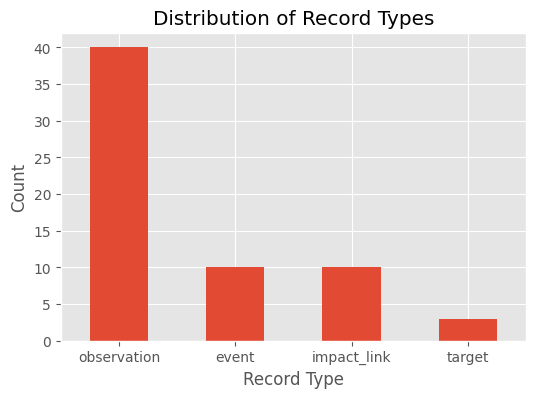

In [56]:
import matplotlib.pyplot as plt

record_counts = enriched_data["record_type"].value_counts()

plt.figure(figsize=(6,4))
record_counts.plot(kind="bar")

plt.title("Distribution of Record Types")
plt.xlabel("Record Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

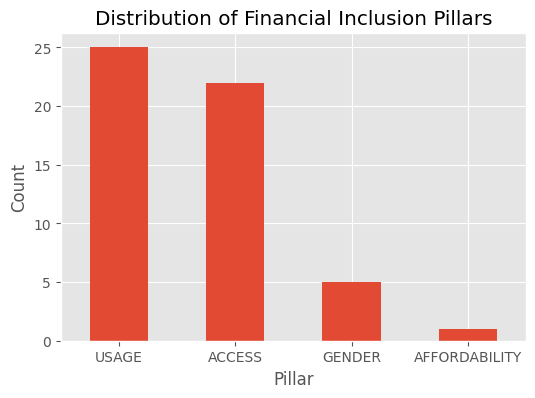

In [57]:
pillar_counts = enriched_data["pillar"].value_counts()

plt.figure(figsize=(6,4))
pillar_counts.plot(kind="bar")

plt.title("Distribution of Financial Inclusion Pillars")
plt.xlabel("Pillar")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

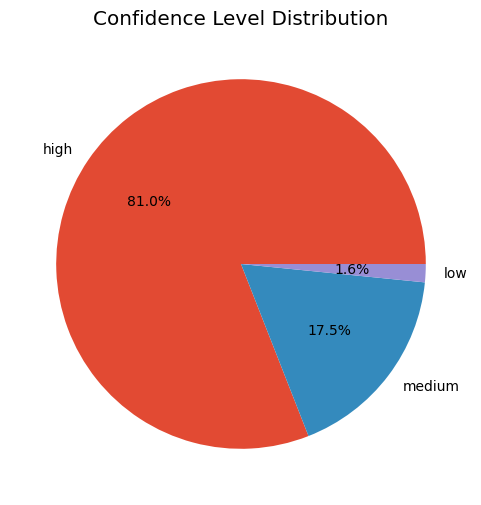

In [58]:
confidence_counts = enriched_data["confidence"].value_counts()

plt.figure(figsize=(6,6))

confidence_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Confidence Level Distribution")

plt.show()

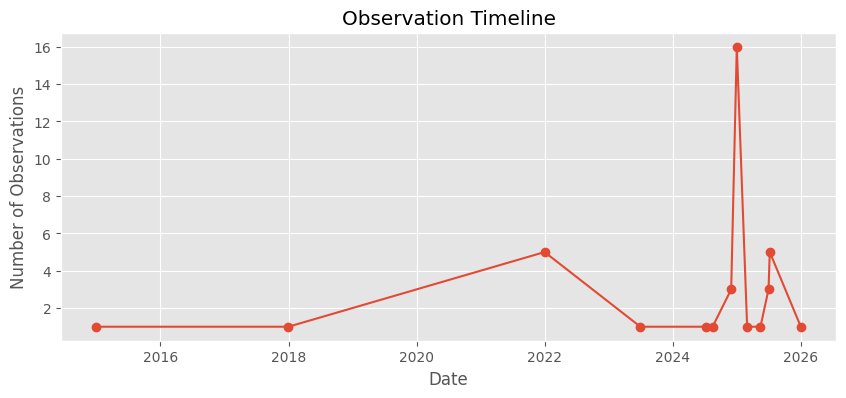

In [59]:
observations = enriched_data[
    enriched_data["record_type"] == "observation"
].copy()

observations["observation_date"] = pd.to_datetime(
    observations["observation_date"]
)

timeline = (
    observations.groupby("observation_date")
    .size()
)

plt.figure(figsize=(10,4))

plt.plot(
    timeline.index,
    timeline.values,
    marker="o"
)

plt.title("Observation Timeline")
plt.xlabel("Date")
plt.ylabel("Number of Observations")

plt.grid(True)

plt.show()